# Portfolio Asset Identification using Graph Algorithms on a QAOA

This notebook demonstrates how **graph theory** and **quantum optimization** can be combined to identify
clusters of highly correlated financial assets.  

We:
1. Construct a correlation graph from historical asset data.
2. Translate the **Maximum Clique Problem** (finding the largest fully connected subgraph) into a **QUBO** formulation.
3. Convert that QUBO into an **Ising Hamiltonian**, the native form for quantum optimization algorithms.
4. Solve it using the **Quantum Approximate Optimization Algorithm (QAOA)** implemented in *PennyLane*.
5. Visualize the selected subset of assets on the correlation graph.

**Goal:** Identify a small set of assets that are strongly correlated (highly connected) — representing potential redundant or sector-linked investments in a portfolio.

### Step 1 — Import Required Libraries

We import classical Python tools for data handling and visualization (`pandas`, `matplotlib`, `networkx`, `yfinance`)
and quantum libraries (`pennylane`, `numpy` wrapper).  
`yfinance` is used to fetch real stock data; `networkx` builds and visualizes graphs; `PennyLane` runs the QAOA.


In [11]:
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import yfinance as yf
import networkx as nx
import matplotlib.pyplot as plt

### Step 2 — Download Historical Data & Compute Correlations

- **Input:** List of asset tickers (S&P 100 subset or custom list).  
- **Process:**  
  1. Download daily adjusted closing prices with *yfinance*.  
  2. Compute daily returns.  
  3. Build a correlation matrix between all asset pairs.
- **Output:** Correlation matrix `corr_matrix` where each entry is the Pearson correlation between asset returns.


In [12]:
# Import live assets to calculate daily returs and correlation matrix
assets = ["AAPL", "MSFT", "NVDA", "JPM", "MA", "XOM", "JNJ", "PG", "KO", "CAT", "META", "DUK"]

# Fetch adjusted close prices
data = yf.download(assets, start="2018-01-01", end="2025-10-31", auto_adjust=True)["Close"]
returns = data.pct_change().dropna()
corr_matrix = returns.corr()

[*********************100%***********************]  12 of 12 completed


### Step 3 — Construct the Correlation Graph

We now represent assets as a graph:

- **Nodes:** Individual assets.  
- **Edges:** Exist if two assets have correlation above a chosen threshold (e.g. 0.45).  
- **Edge Weight:** Strength of correlation (|r|).  

Highly connected clusters indicate groups of assets that behave similarly.
Such graphs are used for *portfolio diversification* analysis and *risk clustering*.

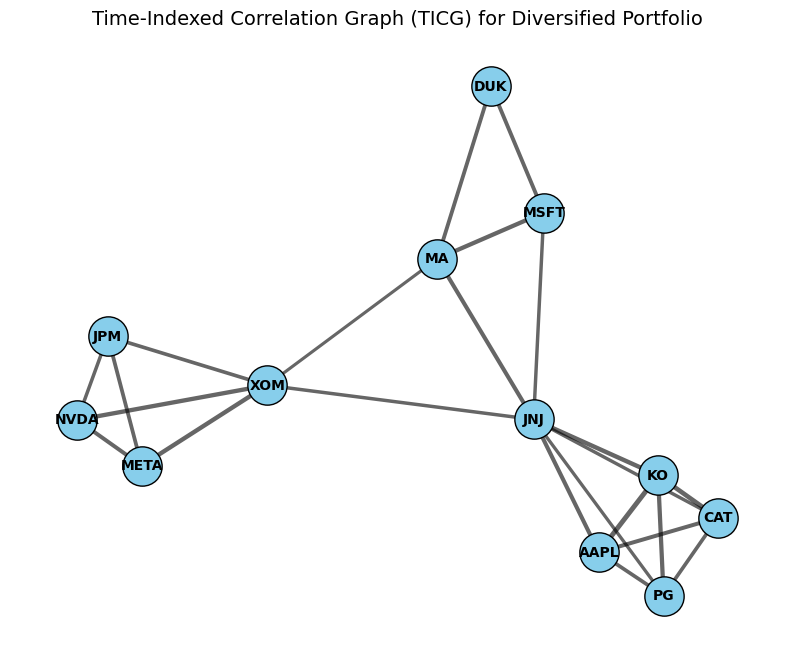


Correlation Matrix (rounded):
Ticker   AAPL    CAT    DUK    JNJ    JPM     KO     MA   META   MSFT   NVDA  \
Ticker                                                                         
AAPL    1.000  0.403  0.269  0.321  0.434  0.356  0.595  0.535  0.705  0.576   
CAT     0.403  1.000  0.242  0.305  0.616  0.333  0.497  0.286  0.407  0.387   
DUK     0.269  0.242  1.000  0.505  0.370  0.623  0.368  0.117  0.270  0.086   
JNJ     0.321  0.305  0.505  1.000  0.364  0.528  0.389  0.158  0.328  0.121   
JPM     0.434  0.616  0.370  0.364  1.000  0.451  0.590  0.331  0.449  0.362   
KO      0.356  0.333  0.623  0.528  0.451  1.000  0.501  0.176  0.363  0.157   
MA      0.595  0.497  0.368  0.389  0.590  0.501  1.000  0.474  0.636  0.490   
META    0.535  0.286  0.117  0.158  0.331  0.176  0.474  1.000  0.611  0.528   
MSFT    0.705  0.407  0.270  0.328  0.449  0.363  0.636  0.611  1.000  0.663   
NVDA    0.576  0.387  0.086  0.121  0.362  0.157  0.490  0.528  0.663  1.000   
PG      0

In [13]:
# ---------------------------
# 3) Build graph
# ---------------------------

# Build graph using absolute correlation threshold
G = nx.Graph()
G.add_nodes_from(assets)  # ensure every asset appears (important for indexing later)

threshold = 0.45
for i in range(len(assets)):
    for j in range(i + 1, len(assets)):
        weight = abs(corr_matrix.iloc[i, j])
        if weight > threshold:
            G.add_edge(assets[i], assets[j], weight=weight)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, weight='weight')
edges = G.edges(data=True)
weights = [d['weight'] * 5 for (_, _, d) in edges]

nx.draw_networkx_nodes(G, pos, node_size=800, node_color="skyblue", edgecolors='k')
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
plt.title("Time-Indexed Correlation Graph (TICG) for Diversified Portfolio", fontsize=14)
plt.axis("off")
plt.show()

print("\nCorrelation Matrix (rounded):")
print(corr_matrix.round(3))

### Step 4 — Build QUBO Formulation for the Maximum Clique Problem

The **Maximum Clique Problem** asks for the largest subset of vertices where every pair is connected.

We express it as a **Quadratic Unconstrained Binary Optimization (QUBO)** problem:

$$
E(x) = \sum_i (-A)\,x_i \;+\; \sum_{(i,j)\notin E(G)} B\,x_i\,x_j
$$

where  

- $ x_i \in \{0,1\} $ indicates whether node *i* is included,  
- **A** is the reward for including a node,  
- **B** is the penalty for including two nodes that are not connected in the original graph.  

Minimizing this energy finds the most connected subset of nodes — the maximum clique.



Number of nodes considered: 12
Nodes order: ['AAPL', 'MSFT', 'NVDA', 'JPM', 'MA', 'XOM', 'JNJ', 'PG', 'KO', 'CAT', 'META', 'DUK']

QUBO matrix (Q):
      AAPL  MSFT  NVDA  JPM   MA  XOM  JNJ   PG   KO  CAT  META  DUK
AAPL  -4.0   2.0   2.0  2.0  2.0  2.0  0.0  0.0  0.0  0.0   2.0  2.0
MSFT   2.0  -4.0   2.0  2.0  0.0  2.0  0.0  2.0  2.0  2.0   2.0  0.0
NVDA   2.0   2.0  -4.0  0.0  2.0  0.0  2.0  2.0  2.0  2.0   0.0  2.0
JPM    2.0   2.0   0.0 -4.0  2.0  0.0  2.0  2.0  2.0  2.0   0.0  2.0
MA     2.0   0.0   2.0  2.0 -4.0  0.0  0.0  2.0  2.0  2.0   2.0  0.0
XOM    2.0   2.0   0.0  0.0  0.0 -4.0  0.0  2.0  2.0  2.0   0.0  2.0
JNJ    0.0   0.0   2.0  2.0  0.0  0.0 -4.0  0.0  0.0  0.0   2.0  2.0
PG     0.0   2.0   2.0  2.0  2.0  2.0  0.0 -4.0  0.0  0.0   2.0  2.0
KO     0.0   2.0   2.0  2.0  2.0  2.0  0.0  0.0 -4.0  0.0   2.0  2.0
CAT    0.0   2.0   2.0  2.0  2.0  2.0  0.0  0.0  0.0 -4.0   2.0  2.0
META   2.0   2.0   0.0  0.0  2.0  0.0  2.0  2.0  2.0  2.0  -4.0  2.0
DUK    2.0   0.0   2.0 

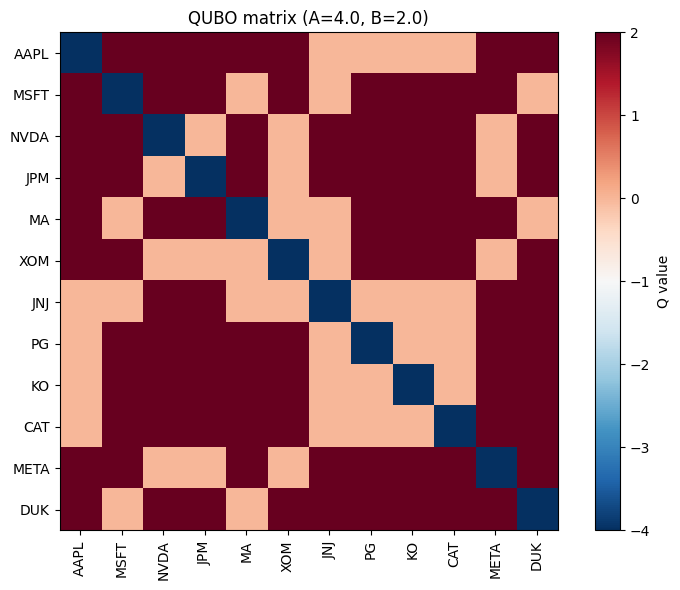

In [14]:
# ---------------------------
# 4) Form QUBO for a max-clique-like objective
#    (your formulation: reward A for selecting a node, penalty B for non-edges)
# ---------------------------
A = 4.0  # reward coefficient (linear) — negative on diagonal to *encourage* selection
B = 2.0  # penalty for selecting two nodes that are not connected (quadratic)

nodes = list(G.nodes())  # consistent ordering used everywhere
n = len(nodes)
print(f"\nNumber of nodes considered: {n}")
print("Nodes order:", nodes)

# Complement graph: edges in G_comp represent non-edges in original graph (penalty pairs)
G_comp = nx.complement(G)

# Build QUBO matrix Q (convention: E(x) = sum_i Q_ii x_i + sum_{i<j} Q_ij x_i x_j)
Q = np.zeros((n, n), dtype=float)
for i in range(n):
    Q[i, i] = -A  # diagonal reward (negative to lower energy when x_i = 1)
for i in range(n):
    for j in range(i + 1, n):
        if G_comp.has_edge(nodes[i], nodes[j]):
            Q[i, j] = Q[j, i] = B  # penalty for non-edge pair

Q_df = pd.DataFrame(Q, index=nodes, columns=nodes)
print("\nQUBO matrix (Q):")
print(Q_df.round(3))

plt.figure(figsize=(8, 6))
plt.imshow(Q, interpolation='nearest', cmap='RdBu_r')
plt.colorbar(label='Q value')
plt.xticks(range(n), nodes, rotation=90)
plt.yticks(range(n), nodes)
plt.title(f"QUBO matrix (A={A}, B={B})")
plt.tight_layout()
plt.show()

### Step 5 — QUBO → Ising Conversion

Quantum circuits use spin variables \(z_i \in \{-1,1\}\) instead of binary \(x_i \in \{0,1\}\).

We apply the transformation  

$$
x_i = \frac{1 - z_i}{2}
$$

to convert the QUBO into an **Ising Hamiltonian**:

$$
H = \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j
$$

with coefficients  

$$
J_{ij} = \frac{Q_{ij}}{4}, \qquad
h_i = -\frac{1}{2}Q_{ii} - \frac{1}{4}\sum_{j\neq i}Q_{ij}
$$

This Hamiltonian represents the cost-energy landscape that QAOA minimizes.


In [15]:
# ---------------------------
# 5) Correct QUBO -> Ising mapping
# Conventions used:
#   - QUBO: E(x) = sum_i Q_ii x_i + sum_{i<j} Q_ij x_i x_j, x in {0,1}
#   - Ising: z in {-1,1}, x_i = (1 - z_i)/2
# Derived mapping:
#   - J_ij = Q_ij / 4
#   - h_i  = -1/2 * Q_ii - 1/4 * sum_{j != i} Q_ij
#   - constant offset C = 1/2 * sum_i Q_ii + 1/4 * sum_{i<j} Q_ij
# ---------------------------
# Make sure Q rows/columns correspond to `nodes` ordering above

# Compute h and J for Ising Hamiltonian H = sum_i h_i Z_i + sum_{i<j} J_ij Z_i Z_j
row_sums = Q.sum(axis=1)
h = np.zeros(n)
J = np.zeros((n, n))
for i in range(n):
    h[i] = -0.5 * Q[i, i] - 0.25 * (row_sums[i] - Q[i, i])
    for j in range(i + 1, n):
        J[i, j] = 0.25 * Q[i, j]

# constant energy offset (optional) so E_z + C = original QUBO energy mapped to z basis
const_offset = 0.5 * np.sum(np.diag(Q)) + 0.25 * np.sum(np.triu(Q, 1))

print("\nIsing coefficients (h):", np.round(h, 4))
print("Sample of Ising J (upper triangle):")
for i in range(n):
    for j in range(i + 1, n):
        if J[i, j] != 0:
            print(f"  J[{nodes[i]},{nodes[j]}] = {J[i, j]:.4f}")


Ising coefficients (h): [-1.5 -2.  -2.  -2.  -1.5 -1.   0.  -1.5 -1.5 -1.5 -2.  -2.5]
Sample of Ising J (upper triangle):
  J[AAPL,MSFT] = 0.5000
  J[AAPL,NVDA] = 0.5000
  J[AAPL,JPM] = 0.5000
  J[AAPL,MA] = 0.5000
  J[AAPL,XOM] = 0.5000
  J[AAPL,META] = 0.5000
  J[AAPL,DUK] = 0.5000
  J[MSFT,NVDA] = 0.5000
  J[MSFT,JPM] = 0.5000
  J[MSFT,XOM] = 0.5000
  J[MSFT,PG] = 0.5000
  J[MSFT,KO] = 0.5000
  J[MSFT,CAT] = 0.5000
  J[MSFT,META] = 0.5000
  J[NVDA,MA] = 0.5000
  J[NVDA,JNJ] = 0.5000
  J[NVDA,PG] = 0.5000
  J[NVDA,KO] = 0.5000
  J[NVDA,CAT] = 0.5000
  J[NVDA,DUK] = 0.5000
  J[JPM,MA] = 0.5000
  J[JPM,JNJ] = 0.5000
  J[JPM,PG] = 0.5000
  J[JPM,KO] = 0.5000
  J[JPM,CAT] = 0.5000
  J[JPM,DUK] = 0.5000
  J[MA,PG] = 0.5000
  J[MA,KO] = 0.5000
  J[MA,CAT] = 0.5000
  J[MA,META] = 0.5000
  J[XOM,PG] = 0.5000
  J[XOM,KO] = 0.5000
  J[XOM,CAT] = 0.5000
  J[XOM,DUK] = 0.5000
  J[JNJ,META] = 0.5000
  J[JNJ,DUK] = 0.5000
  J[PG,META] = 0.5000
  J[PG,DUK] = 0.5000
  J[KO,META] = 0.5000
  J[KO,DUK

### Step 6 — Define the QAOA Quantum Circuit

QAOA alternates between two unitaries:

1. **Cost Hamiltonian:** $ U_C(\gamma)=e^{-i\gamma H_C} $
2. **Mixer Hamiltonian:** $ U_M(\beta)=e^{-i\beta\sum_i X_i} $

Each layer pair is controlled by parameters $(\gamma,\beta)$.
The algorithm starts with a uniform superposition and steers probability toward low-energy (optimal) states.


In [16]:
# ---------------------------
# 6) QAOA circuit (PennyLane)
# ---------------------------
# WARNING: simulation size grows exponentially with n. For n=12 this may be slow.
p = 5  # QAOA depth — increase if you have the compute to handle it

dev_analytic = qml.device("default.qubit", wires=n)
dev_sample = qml.device("default.qubit", wires=n, shots=2000)

# Use RNG for reproducibility
rng = np.random.default_rng(seed=42)

def cost_layer(gamma):
    """Apply e^{-i gamma H_C} where H_C = sum_i h_i Z_i + sum_{i<j} J_ij Z_i Z_j."""
    # Single-qubit Z terms (RZ): RZ(phi) = exp(-i phi/2 Z) so phi = 2 * gamma * h_i
    for i in range(n):
        if abs(h[i]) > 0.0:
            qml.RZ(2.0 * h[i] * gamma, wires=i)
    # Two-qubit ZZ terms: qml.IsingZZ(theta) implements exp(-i theta/2 Z⊗Z).
    # To implement exp(-i gamma * J_ij * Z_i Z_j) we set theta = 2 * gamma * J_ij.
    for i in range(n):
        for j in range(i + 1, n):
            if abs(J[i, j]) > 0.0:
                qml.IsingZZ(2.0 * J[i, j] * gamma, wires=[i, j])

def mixer_layer(beta):
    """Apply e^{-i beta sum X_i} implemented as RX(2*beta) on each qubit."""
    for i in range(n):
        qml.RX(2.0 * beta, wires=i)

@qml.qnode(dev_analytic)
def qaoa_expectation(params):
    gammas = params[:p]
    betas = params[p:]
    # Initial layer: uniform superposition
    for i in range(n):
        qml.Hadamard(wires=i)
    # p alternating layers
    for layer in range(p):
        cost_layer(gammas[layer])
        mixer_layer(betas[layer])
    # Build Hamiltonian observables for expectation
    coeffs = []
    obs = []
    for i in range(n):
        if abs(h[i]) > 0.0:
            coeffs.append(h[i])
            obs.append(qml.PauliZ(i))
    for i in range(n):
        for j in range(i + 1, n):
            if abs(J[i, j]) > 0.0:
                coeffs.append(J[i, j])
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
    H = qml.Hamiltonian(coeffs, obs)
    # Return expected Ising energy (note: you can add const_offset if you want QUBO energy comparison)
    return qml.expval(H)  # + const_offset  <-- optionally add to compare with original QUBO energies

### Step 7 — Optimize Parameters Classically

A classical optimizer (Adam) adjusts $\gamma$ and $\beta$ to minimize the expected energy:

$$
\langle \psi(\gamma,\beta)\,|\,H\,|\,\psi(\gamma,\beta)\rangle
$$

Lower energy corresponds to a more optimal clique configuration.


In [17]:
# ---------------------------
# 7) Classical optimizer
# ---------------------------
init_params = rng.uniform(low=0.0, high=0.1, size=(2 * p,))  # small init helps optimization
params = np.array(init_params, requires_grad=True)

opt = qml.AdamOptimizer(stepsize=0.001)
maxiter = 300

print("\nStarting QAOA optimization...")
for it in range(maxiter):
    params, prev_cost = opt.step_and_cost(qaoa_expectation, params)
    if (it % 10 == 0) or (it == maxiter - 1):
        print(f"Iter {it:03d} | Energy = {prev_cost:.6f}")
print("Optimization finished.")
print("Optimal params (gamma[0..], beta[0..]):", params)


Starting QAOA optimization...
Iter 000 | Energy = 9.305564
Iter 010 | Energy = 6.877155
Iter 020 | Energy = 4.585518
Iter 030 | Energy = 2.579474
Iter 040 | Energy = 0.964734
Iter 050 | Energy = -0.246395
Iter 060 | Energy = -1.142782
Iter 070 | Energy = -1.851035
Iter 080 | Energy = -2.466945
Iter 090 | Energy = -3.027601
Iter 100 | Energy = -3.538303
Iter 110 | Energy = -4.005846
Iter 120 | Energy = -4.441310
Iter 130 | Energy = -4.851439
Iter 140 | Energy = -5.239741
Iter 150 | Energy = -5.609562
Iter 160 | Energy = -5.963592
Iter 170 | Energy = -6.303505
Iter 180 | Energy = -6.630262
Iter 190 | Energy = -6.944306
Iter 200 | Energy = -7.245544
Iter 210 | Energy = -7.533055
Iter 220 | Energy = -7.804767
Iter 230 | Energy = -8.057453
Iter 240 | Energy = -8.287285
Iter 250 | Energy = -8.490981
Iter 260 | Energy = -8.667201
Iter 270 | Energy = -8.817538
Iter 280 | Energy = -8.946465
Iter 290 | Energy = -9.060144
Iter 299 | Energy = -9.154519
Optimization finished.
Optimal params (gamma

### Step 8 — Sampling and Extracting Solutions

After optimization, we sample the quantum circuit many times (≈ 2000 shots).  
Each measurement produces a bitstring $x \in \{0,1\}^n$.  
The most frequent bitstring represents the minimum-energy configuration.

Each ‘1’ in that bitstring corresponds to a selected asset in the clique.

In [18]:
# ---------------------------
# 8) Sampling with optimized params
# ---------------------------
@qml.qnode(dev_sample)
def sample_qaoa(params):
    gammas = params[:p]
    betas = params[p:]
    for i in range(n):
        qml.Hadamard(wires=i)
    for layer in range(p):
        cost_layer(gammas[layer])
        mixer_layer(betas[layer])
    return qml.sample(wires=range(n))

print("\nSampling from optimized circuit (shots = {})...".format(dev_sample.shots))
samples = sample_qaoa(params)  # array shape: (shots, n)
samples = np.array(samples)

# Convert to bitstrings and counts
bitstrings = ["".join(str(int(b)) for b in s) for s in samples]
(unique, counts) = np.unique(bitstrings, return_counts=True)
sorted_results = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)

print("\nMost probable bitstrings and selected nodes (top 5):")
for bs, count in sorted_results[:5]:
    selected = [nodes[i] for i, bit in enumerate(bs) if bit == "1"]
    percentage = 100.0 * count / len(samples)
    print(f"{bs} -> {count} samples ({percentage:.2f}%) | Selected: {selected if selected else 'None'}")


Sampling from optimized circuit (shots = Shots(total=2000))...

Most probable bitstrings and selected nodes (top 5):
100000111100 -> 142 samples (7.10%) | Selected: ['AAPL', 'JNJ', 'PG', 'KO', 'CAT']
001101000010 -> 119 samples (5.95%) | Selected: ['NVDA', 'JPM', 'XOM', 'META']
010010100001 -> 38 samples (1.90%) | Selected: ['MSFT', 'MA', 'JNJ', 'DUK']
100000011100 -> 36 samples (1.80%) | Selected: ['AAPL', 'PG', 'KO', 'CAT']
010011100001 -> 27 samples (1.35%) | Selected: ['MSFT', 'MA', 'XOM', 'JNJ', 'DUK']


### Step 9 — Visualize the QAOA-Selected Portfolio Nodes

We highlight the nodes corresponding to 1-bits in the best bitstring on the original correlation graph:

- **Gold nodes:** selected assets in the clique.  
- **Gray nodes:** unselected assets.  
- **Orange edges (optional):** edges between selected nodes (the clique itself).  

This visualization links the quantum solution back to its financial interpretation — which assets form the tightest correlation cluster.



Best bitstring: 100000111100
Selected nodes: ['AAPL', 'JNJ', 'PG', 'KO', 'CAT']


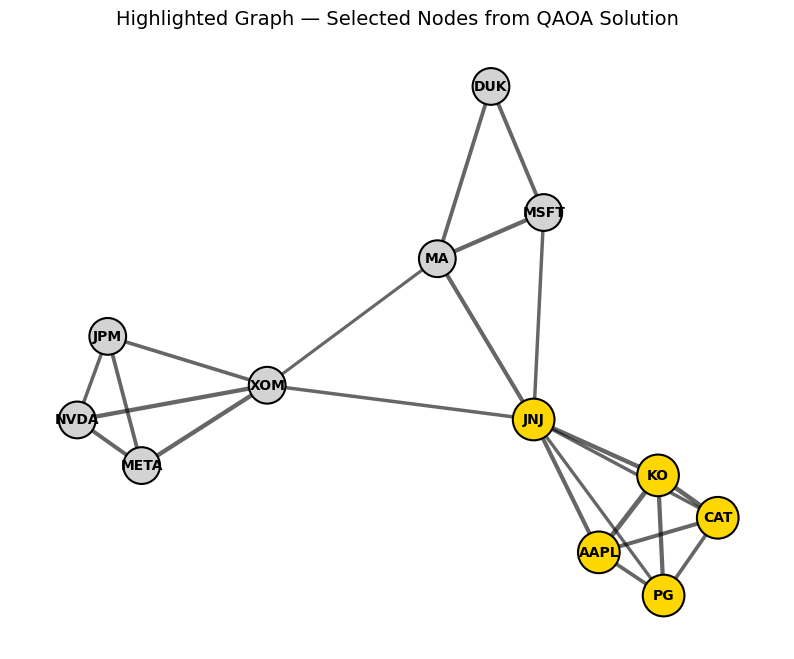

In [19]:
best_bitstring, _ = sorted_results[0]
selected_nodes = [nodes[i] for i, bit in enumerate(best_bitstring) if bit == "1"]

print("\nBest bitstring:", best_bitstring)
print("Selected nodes:", selected_nodes)

# Redraw the graph with selected nodes highlighted
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, weight='weight')  # reuse same layout for consistency

# Color all nodes, highlight selected ones
node_colors = ["gold" if node in selected_nodes else "lightgray" for node in G.nodes()]
node_sizes = [900 if node in selected_nodes else 700 for node in G.nodes()]

# Edge weights for consistent visualization
edges = G.edges(data=True)
weights = [d['weight'] * 5 for (_, _, d) in edges]

# Draw
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, edgecolors='k', linewidths=1.5)
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title("Highlighted Graph — Selected Nodes from QAOA Solution", fontsize=14)
plt.axis("off")
plt.show()